In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/feature_engineered.csv"
)

print("Dataset shape:", df.shape)
print(df.head())

C:\Users\Naveen kumar\AppData\Local\Temp\ipykernel_27184\3682199530.py:4: DtypeWarning: Columns (0: exercise_intensity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dataset shape: (64283, 66)
           Patient            timestamp  glucose_value meal_type  meal_carbs  \
0  540-ws-training  2027-05-19 11:36:29             76      none         0.0   
1  540-ws-training  2027-05-19 11:41:29             72      none         0.0   
2  540-ws-training  2027-05-19 11:46:29             68      none         0.0   
3  540-ws-training  2027-05-19 11:51:29             65      none         0.0   
4  540-ws-training  2027-05-19 11:56:29             63      none         0.0   

  bolus_type  bolus_dose  basal_value  temp_basal_value exercise_type  ...  \
0     normal         0.8         0.95               0.0          none  ...   
1     normal         0.8         0.95               0.0          none  ...   
2     normal         0.8         0.95               0.0          none  ...   
3     normal         0.8         0.95               0.0          none  ...   
4     normal         0.8         0.95               0.0          none  ...   

   sleep_change gsr_rol

In [3]:
selected_features = [
    # Glucose
    "glucose_value",
    "glucose_prev_5min",
    "glucose_prev_10min",
    "glucose_prev_15min",
    "glucose_prev_30min",
    "glucose_change_5min",
    "glucose_change_10min",
    "glucose_change_15min",
    "glucose_change_30min",
    "glucose_rate_5min",
    "glucose_rate_15min",
    "glucose_rate_30min",
    "glucose_rolling_mean_15min",
    "glucose_rolling_mean_30min",
    "glucose_rolling_std_30min",
    "glucose_min_30min",
    "glucose_max_30min",

    # Insulin
    "bolus_given",
    "bolus_dose_filled",
    "basal_value",
    "basal_rolling_30min",
    "basal_rolling_60min",
    "temp_basal_active",
    "effective_basal",
    "basal_change",

    # Meal
    "meal_event",
    "meal_carbs",

    # Exercise
    "exercise_event",
    "exercise_duration",

    # Time
    "hour",
    "day_of_week",
    "is_weekend"
]

X = df[selected_features].copy()
y = df["glucose_30min_ahead"].copy()

print("Number of features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 32
X shape: (64283, 32)
y shape: (64283,)


In [4]:
missing = X.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

glucose_prev_30min           36
glucose_change_30min         36
glucose_rate_30min           36
glucose_prev_15min           18
glucose_rate_15min           18
glucose_change_15min         18
glucose_change_10min         12
glucose_prev_10min           12
glucose_prev_5min             6
glucose_change_5min           6
glucose_rate_5min             6
glucose_rolling_std_30min     6
dtype: int64


In [5]:
print("Total missing values:", X.isna().sum().sum())

Total missing values: 210


In [6]:
print(X.dtypes)

glucose_value                   int64
glucose_prev_5min             float64
glucose_prev_10min            float64
glucose_prev_15min            float64
glucose_prev_30min            float64
glucose_change_5min           float64
glucose_change_10min          float64
glucose_change_15min          float64
glucose_change_30min          float64
glucose_rate_5min             float64
glucose_rate_15min            float64
glucose_rate_30min            float64
glucose_rolling_mean_15min    float64
glucose_rolling_mean_30min    float64
glucose_rolling_std_30min     float64
glucose_min_30min             float64
glucose_max_30min             float64
bolus_given                     int64
bolus_dose_filled             float64
basal_value                   float64
basal_rolling_30min           float64
basal_rolling_60min           float64
temp_basal_active               int64
effective_basal               float64
basal_change                  float64
meal_event                      int64
meal_carbs  

In [7]:
df = df.sort_values(["Patient", "timestamp"]).reset_index(drop=True)

train_parts = []
test_parts = []

for patient, patient_df in df.groupby("Patient"):
    split_index = int(len(patient_df) * 0.8)

    train_parts.append(patient_df.iloc[:split_index])
    test_parts.append(patient_df.iloc[split_index:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (51424, 66)
Test : (12859, 66)


In [8]:
X_train = train_df[selected_features].copy()
X_test = test_df[selected_features].copy()

y_train = train_df["glucose_30min_ahead"].copy()
y_test = test_df["glucose_30min_ahead"].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (51424, 32)
X_test : (12859, 32)
y_train: (51424,)
y_test : (12859,)


In [9]:
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing in X_train:", X_train.isna().sum().sum())
print("Missing in X_test :", X_test.isna().sum().sum())

Missing in X_train: 0
Missing in X_test : 0


In [10]:
X_train_np = X_train.astype("float32").values
X_test_np = X_test.astype("float32").values

y_train_np = y_train.astype("float32").values
y_test_np = y_test.astype("float32").values

print("X_train shape:", X_train_np.shape)
print("Any NaN:", np.isnan(X_train_np).any())
print("Any Inf:", np.isinf(X_train_np).any())

X_train shape: (51424, 32)
Any NaN: False
Any Inf: False


In [11]:
X_train_np = X_train.astype("float32").values
X_test_np = X_test.astype("float32").values

y_train_np = y_train.astype("float32").values
y_test_np = y_test.astype("float32").values

print("X_train shape:", X_train_np.shape)
print("Any NaN:", np.isnan(X_train_np).any())
print("Any Inf:", np.isinf(X_train_np).any())

X_train shape: (51424, 32)
Any NaN: False
Any Inf: False


In [12]:
import tensorflow as tf

normalizer = tf.keras.layers.Normalization()

normalizer.adapt(X_train_np)

print("Normalization complete.")

Normalization complete.


In [13]:
model = tf.keras.Sequential([
    normalizer,

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),

    # Regression output
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (51424, 32)            │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (264.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 65 (264.00 B)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_np,
    y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

print("Training complete.")

Epoch 1/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4645.5908 - mae: 46.3733 - val_loss: 3325.9675 - val_mae: 48.6204
Epoch 2/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1098.8213 - mae: 24.9572 - val_loss: 1983.1593 - val_mae: 36.5976
Epoch 3/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 972.4368 - mae: 23.4817 - val_loss: 1337.5736 - val_mae: 29.1540
Epoch 4/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 908.0348 - mae: 22.6923 - val_loss: 868.4789 - val_mae: 22.0876
Epoch 5/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 869.9170 - mae: 22.1604 - val_loss: 796.2984 - val_mae: 20.8002
Epoch 6/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 850.5038 - mae: 21.8770 - val_loss: 716.9548 - val_mae: 19.5237
Epoch 7/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 826.0073 - mae: 21.5755 - val_loss: 729.0406 - val_mae: 19.6064
Epoch 8/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 802.2916 - mae: 21.2123 - val_loss: 731.1602 - val_mae: 19.5284
Ep

In [16]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_pred = model.predict(X_test_np).flatten()

mae = mean_absolute_error(y_test_np, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
r2 = r2_score(y_test_np, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE : 16.543886184692383
RMSE: 23.336770522041764
R²  : 0.8559333086013794


In [17]:
print("Prediction min :", y_pred.min())
print("Prediction max :", y_pred.max())
print("Prediction mean:", y_pred.mean())

Prediction min : 71.3277
Prediction max : 502.3746
Prediction mean: 163.6225


In [18]:
!pip install matplotlib


Looking in indexes: https://pypi.org/simple/


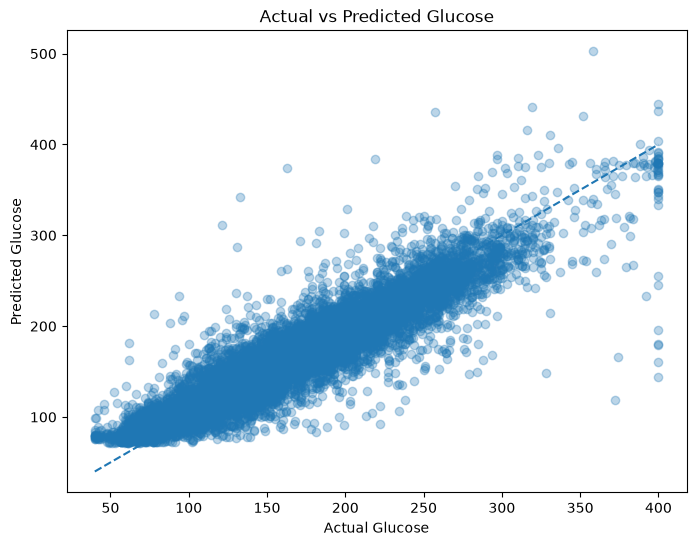

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_np,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Actual vs Predicted Glucose")

# Perfect prediction line
plt.plot(
    [y_test_np.min(), y_test_np.max()],
    [y_test_np.min(), y_test_np.max()],
    linestyle="--"
)

plt.show()

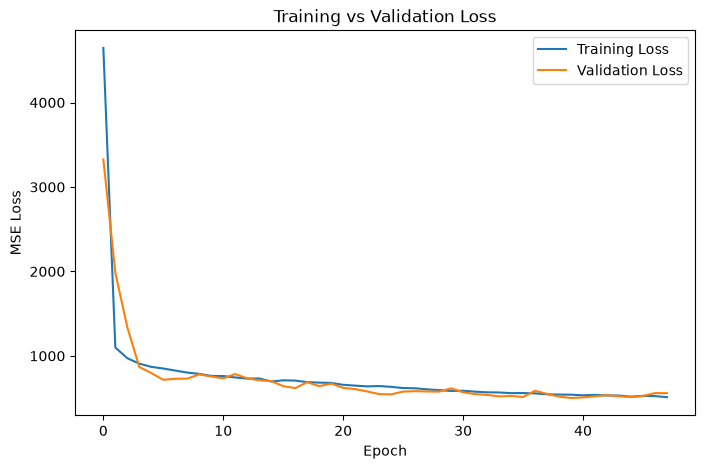

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [21]:
pip install scikeras


Looking in indexes: https://pypi.org/simple/
Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

baseline_pred = model.predict(X_test_np, verbose=0).ravel()
baseline_mae = mean_absolute_error(y_test_np, baseline_pred)

rng = np.random.RandomState(42)
all_importances = np.zeros(
    (len(selected_features), 3)
)

for i in range(len(selected_features)):

    for r in range(3):

        X_permuted = X_test_np.copy()

        shuffled_indices = rng.permutation(len(X_permuted))
        X_permuted[:, i] = X_permuted[shuffled_indices, i]

        pred = model.predict(
            X_permuted,
            verbose=0
        ).ravel()

        permuted_mae = mean_absolute_error(
            y_test_np,
            pred
        )

        all_importances[i, r] = permuted_mae - baseline_mae

importance = pd.DataFrame({
    "feature": selected_features,
    "importance": all_importances.mean(axis=1)
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

                       feature  importance
1            glucose_prev_5min    3.814347
2           glucose_prev_10min    3.088926
0                glucose_value    2.940631
12  glucose_rolling_mean_15min    2.156042
15           glucose_min_30min    1.982123
16           glucose_max_30min    1.721474
13  glucose_rolling_mean_30min    1.701626
9            glucose_rate_5min    1.576574
4           glucose_prev_30min    1.554309
21         basal_rolling_60min    1.267008
5          glucose_change_5min    1.211320
3           glucose_prev_15min    1.209002
11          glucose_rate_30min    0.704823
8         glucose_change_30min    0.696397
10          glucose_rate_15min    0.601521
7         glucose_change_15min    0.406425
28           exercise_duration    0.397764
23             effective_basal    0.260882
14   glucose_rolling_std_30min    0.246560
18           bolus_dose_filled    0.149430
20         basal_rolling_30min    0.127707
6         glucose_change_10min    0.125305
29         

In [23]:
print(importance.head(15))

                       feature  importance
1            glucose_prev_5min    3.814347
2           glucose_prev_10min    3.088926
0                glucose_value    2.940631
12  glucose_rolling_mean_15min    2.156042
15           glucose_min_30min    1.982123
16           glucose_max_30min    1.721474
13  glucose_rolling_mean_30min    1.701626
9            glucose_rate_5min    1.576574
4           glucose_prev_30min    1.554309
21         basal_rolling_60min    1.267008
5          glucose_change_5min    1.211320
3           glucose_prev_15min    1.209002
11          glucose_rate_30min    0.704823
8         glucose_change_30min    0.696397
10          glucose_rate_15min    0.601521


In [24]:
glucose_features = [
    "glucose_value",
    "glucose_prev_5min",
    "glucose_prev_10min",
    "glucose_prev_15min",
    "glucose_prev_30min",
    "glucose_change_5min",
    "glucose_change_10min",
    "glucose_change_15min",
    "glucose_change_30min",
    "glucose_rate_5min",
    "glucose_rate_15min",
    "glucose_rate_30min",
    "glucose_rolling_mean_15min",
    "glucose_rolling_mean_30min",
    "glucose_rolling_std_30min",
    "glucose_min_30min",
    "glucose_max_30min"
]

X_glucose = df[glucose_features].copy()
y = df["glucose_30min_ahead"].copy()

print("Glucose features:", len(glucose_features))
print(X_glucose.shape)

Glucose features: 17
(64283, 17)


In [25]:
X_glucose = df[glucose_features].copy()
y = df["glucose_30min_ahead"].copy()

print("Number of features:", X_glucose.shape[1])
print("Dataset shape:", X_glucose.shape)

Number of features: 17
Dataset shape: (64283, 17)


In [26]:
df_temp = df[["Patient", "timestamp"] + glucose_features + ["glucose_30min_ahead"]].copy()

df_temp = df_temp.sort_values(
    ["Patient", "timestamp"]
).reset_index(drop=True)

train_parts = []
test_parts = []

for patient, patient_df in df_temp.groupby("Patient"):
    split_index = int(len(patient_df) * 0.8)

    train_parts.append(patient_df.iloc[:split_index])
    test_parts.append(patient_df.iloc[split_index:])

train_glucose = pd.concat(train_parts).reset_index(drop=True)
test_glucose = pd.concat(test_parts).reset_index(drop=True)

print("Train:", train_glucose.shape)
print("Test :", test_glucose.shape)

Train: (51424, 20)
Test : (12859, 20)


In [27]:
Xg_train = train_glucose[glucose_features].copy()
Xg_test = test_glucose[glucose_features].copy()

yg_train = train_glucose["glucose_30min_ahead"].copy()
yg_test = test_glucose["glucose_30min_ahead"].copy()

In [28]:
g_medians = Xg_train.median()

Xg_train = Xg_train.fillna(g_medians)
Xg_test = Xg_test.fillna(g_medians)

print("Train missing:", Xg_train.isna().sum().sum())
print("Test missing :", Xg_test.isna().sum().sum())

Train missing: 0
Test missing : 0


In [29]:
Xg_train_np = Xg_train.astype("float32").values
Xg_test_np = Xg_test.astype("float32").values

yg_train_np = yg_train.astype("float32").values
yg_test_np = yg_test.astype("float32").values

print(Xg_train_np.shape)
print(Xg_test_np.shape)

(51424, 17)
(12859, 17)


In [30]:
normalizer_g = tf.keras.layers.Normalization()

normalizer_g.adapt(Xg_train_np)

model_g = tf.keras.Sequential([
    normalizer_g,

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),

    tf.keras.layers.Dense(1)
])

model_g.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_g.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (51424, 17)            │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (144.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 35 (144.00 B)

In [31]:
early_stopping_g = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_g = model_g.fit(
    Xg_train_np,
    yg_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping_g],
    verbose=1
)

Epoch 1/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6628.0776 - mae: 59.3273 - val_loss: 995.1976 - val_mae: 20.8659
Epoch 2/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1184.0035 - mae: 25.2940 - val_loss: 611.1422 - val_mae: 16.0503
Epoch 3/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 959.4176 - mae: 23.0641 - val_loss: 511.3680 - val_mae: 14.6323
Epoch 4/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 888.6391 - mae: 22.1855 - val_loss: 486.1837 - val_mae: 14.2167
Epoch 5/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 865.5904 - mae: 21.9693 - val_loss: 508.3884 - val_mae: 14.7170
Epoch 6/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 835.0430 - mae: 21.5431 - val_loss: 502.0995 - val_mae: 14.6450
Epoch 7/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 817.1053 - mae: 21.2748 - val_loss: 488.0270 - val_mae: 14.5499
Epoch 8/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 775.8434 - mae: 20.6659 - val_loss: 542.1141 - val_mae: 15.9627
Epoch 

In [32]:
yg_pred = model_g.predict(Xg_test_np).flatten()

mae_g = mean_absolute_error(yg_test_np, yg_pred)
rmse_g = np.sqrt(mean_squared_error(yg_test_np, yg_pred))
r2_g = r2_score(yg_test_np, yg_pred)

print("Glucose-only model")
print("MAE :", mae_g)
print("RMSE:", rmse_g)
print("R²  :", r2_g)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Glucose-only model
MAE : 16.42384910583496
RMSE: 24.894836184485
R²  : 0.8360540866851807


In [33]:
insulin_features = [
    "bolus_given",
    "bolus_dose_filled",
    "basal_value",
    "basal_rolling_30min",
    "basal_rolling_60min",
    "temp_basal_active",
    "effective_basal",
    "basal_change"
]

In [34]:
glucose_insulin_features = glucose_features + insulin_features

print("Total features:", len(glucose_insulin_features))

Total features: 25


In [35]:
X_gi = df[glucose_insulin_features].copy()

df_gi = df[
    ["Patient", "timestamp", "glucose_30min_ahead"] +
    glucose_insulin_features
].copy()

df_gi = df_gi.sort_values(
    ["Patient", "timestamp"]
).reset_index(drop=True)

In [36]:
train_parts = []
test_parts = []

for patient, patient_df in df_gi.groupby("Patient"):
    split_index = int(len(patient_df) * 0.8)

    train_parts.append(patient_df.iloc[:split_index])
    test_parts.append(patient_df.iloc[split_index:])

train_gi = pd.concat(train_parts).reset_index(drop=True)
test_gi = pd.concat(test_parts).reset_index(drop=True)

In [37]:
Xgi_train = train_gi[glucose_insulin_features].copy()
Xgi_test = test_gi[glucose_insulin_features].copy()

ygi_train = train_gi["glucose_30min_ahead"].copy()
ygi_test = test_gi["glucose_30min_ahead"].copy()

In [38]:
gi_medians = Xgi_train.median()

Xgi_train = Xgi_train.fillna(gi_medians)
Xgi_test = Xgi_test.fillna(gi_medians)

In [39]:
Xgi_train_np = Xgi_train.astype("float32").values
Xgi_test_np = Xgi_test.astype("float32").values

ygi_train_np = ygi_train.astype("float32").values
ygi_test_np = ygi_test.astype("float32").values

In [40]:
normalizer_gi = tf.keras.layers.Normalization()
normalizer_gi.adapt(Xgi_train_np)

model_gi = tf.keras.Sequential([
    normalizer_gi,

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),

    tf.keras.layers.Dense(1)
])

model_gi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [41]:
early_stopping_gi = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_gi = model_gi.fit(
    Xgi_train_np,
    ygi_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping_gi],
    verbose=1
)

Epoch 1/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4873.2612 - mae: 48.8179 - val_loss: 839.4244 - val_mae: 19.1532
Epoch 2/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1116.0392 - mae: 25.1282 - val_loss: 608.8354 - val_mae: 15.9040
Epoch 3/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 959.4053 - mae: 23.1502 - val_loss: 494.6311 - val_mae: 14.9391
Epoch 4/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 895.9225 - mae: 22.3998 - val_loss: 499.8314 - val_mae: 14.4914
Epoch 5/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 872.2799 - mae: 22.0049 - val_loss: 480.9143 - val_mae: 14.5868
Epoch 6/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 826.6545 - mae: 21.5942 - val_loss: 485.1965 - val_mae: 14.4766
Epoch 7/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 824.4833 - mae: 21.4118 - val_loss: 488.8839 - val_mae: 14.9648
Epoch 8/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 815.5376 - mae: 21.2601 - val_loss: 462.5251 - val_mae: 14.4555
Epoch

In [42]:
ygi_pred = model_gi.predict(Xgi_test_np).flatten()

mae_gi = mean_absolute_error(ygi_test_np, ygi_pred)
rmse_gi = np.sqrt(mean_squared_error(ygi_test_np, ygi_pred))
r2_gi = r2_score(ygi_test_np, ygi_pred)

print("Glucose + Insulin")
print("MAE :", mae_gi)
print("RMSE:", rmse_gi)
print("R²  :", r2_gi)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Glucose + Insulin
MAE : 16.39856719970703
RMSE: 23.50282952338864
R²  : 0.8538757562637329


In [43]:
meal_features = [
    "meal_event",
    "meal_carbs"
]

glucose_insulin_meal_features = (
    glucose_features
    + insulin_features
    + meal_features
)

print("Number of features:", len(glucose_insulin_meal_features))

Number of features: 27


In [44]:
df_gim = df[["Patient", "timestamp", "glucose_30min_ahead"]
            + glucose_insulin_meal_features].copy()

df_gim = df_gim.sort_values(
    ["Patient", "timestamp"]
).reset_index(drop=True)

print(df_gim.shape)
print(df_gim.head())

(64283, 30)
           Patient            timestamp  glucose_30min_ahead  glucose_value  \
0  540-ws-training  2027-05-19 11:36:29                 71.0             76   
1  540-ws-training  2027-05-19 11:41:29                 78.0             72   
2  540-ws-training  2027-05-19 11:46:29                 90.0             68   
3  540-ws-training  2027-05-19 11:51:29                 99.0             65   
4  540-ws-training  2027-05-19 11:56:29                110.0             63   

   glucose_prev_5min  glucose_prev_10min  glucose_prev_15min  \
0                NaN                 NaN                 NaN   
1               76.0                 NaN                 NaN   
2               72.0                76.0                 NaN   
3               68.0                72.0                76.0   
4               65.0                68.0                72.0   

   glucose_prev_30min  glucose_change_5min  glucose_change_10min  ...  \
0                 NaN                  NaN             

In [45]:
train_parts = []
test_parts = []

for patient, patient_df in df_gim.groupby("Patient"):

    split_index = int(len(patient_df) * 0.8)

    train_parts.append(patient_df.iloc[:split_index])
    test_parts.append(patient_df.iloc[split_index:])

train_gim = pd.concat(train_parts).reset_index(drop=True)
test_gim = pd.concat(test_parts).reset_index(drop=True)

print("Train:", train_gim.shape)
print("Test :", test_gim.shape)

Train: (51424, 30)
Test : (12859, 30)


In [46]:
Xgim_train = train_gim[glucose_insulin_meal_features].copy()
Xgim_test = test_gim[glucose_insulin_meal_features].copy()

ygim_train = train_gim["glucose_30min_ahead"].copy()
ygim_test = test_gim["glucose_30min_ahead"].copy()

In [47]:
numeric_cols = Xgim_train.select_dtypes(
    include=np.number
).columns

train_medians_gim = Xgim_train[numeric_cols].median()

Xgim_train[numeric_cols] = Xgim_train[numeric_cols].fillna(
    train_medians_gim
)

Xgim_test[numeric_cols] = Xgim_test[numeric_cols].fillna(
    train_medians_gim
)

In [48]:
Xgim_train_np = Xgim_train.astype("float32").values
Xgim_test_np = Xgim_test.astype("float32").values

ygim_train_np = ygim_train.astype("float32").values
ygim_test_np = ygim_test.astype("float32").values

In [49]:
print("NaN:", np.isnan(Xgim_train_np).sum())
print("Inf:", np.isinf(Xgim_train_np).sum())

NaN: 0
Inf: 0


In [50]:
normalizer_gim = tf.keras.layers.Normalization()
normalizer_gim.adapt(Xgim_train_np)

model_gim = tf.keras.Sequential([
    normalizer_gim,

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),

    tf.keras.layers.Dense(1)
])

model_gim.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [51]:
early_stopping_gim = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_gim = model_gim.fit(
    Xgim_train_np,
    ygim_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping_gim],
    verbose=1
)

Epoch 1/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6025.4258 - mae: 55.2941 - val_loss: 1049.8300 - val_mae: 22.1863
Epoch 2/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1222.5066 - mae: 26.2571 - val_loss: 682.7534 - val_mae: 17.4896
Epoch 3/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1002.4331 - mae: 23.8118 - val_loss: 558.0174 - val_mae: 15.8643
Epoch 4/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 935.1968 - mae: 23.0590 - val_loss: 543.6454 - val_mae: 15.4281
Epoch 5/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 892.0375 - mae: 22.4587 - val_loss: 533.7050 - val_mae: 15.3520
Epoch 6/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 869.3202 - mae: 22.1433 - val_loss: 515.8555 - val_mae: 15.1164
Epoch 7/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 844.7983 - mae: 21.7846 - val_loss: 471.8788 - val_mae: 14.3046
Epoch 8/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 842.0859 - mae: 21.7461 - val_loss: 485.9169 - val_mae: 14.4963
Epoc

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ygim_pred = model_gim.predict(Xgim_test_np).flatten()

mae_gim = mean_absolute_error(
    ygim_test_np,
    ygim_pred
)

rmse_gim = np.sqrt(
    mean_squared_error(
        ygim_test_np,
        ygim_pred
    )
)

r2_gim = r2_score(
    ygim_test_np,
    ygim_pred
)

print("Glucose + Insulin + Meal")
print("MAE :", mae_gim)
print("RMSE:", rmse_gim)
print("R²  :", r2_gim)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Glucose + Insulin + Meal
MAE : 16.49854278564453
RMSE: 23.857925780725235
R²  : 0.8494268655776978


In [53]:
exercise_features = [
    "exercise_event",
    "exercise_duration"
]

glucose_insulin_exercise_features = (
    glucose_features
    + insulin_features
    + exercise_features
)

print("Number of features:", len(glucose_insulin_exercise_features))

Number of features: 27


In [55]:
df_gie = df[
    ["Patient", "timestamp", "glucose_30min_ahead"]
    + glucose_insulin_exercise_features
].copy()

df_gie = df_gie.sort_values(
    ["Patient", "timestamp"]
).reset_index(drop=True)

train_parts = []
test_parts = []

for patient, patient_df in df_gie.groupby("Patient"):

    split_index = int(len(patient_df) * 0.8)

    train_parts.append(patient_df.iloc[:split_index])
    test_parts.append(patient_df.iloc[split_index:])

train_gie = pd.concat(train_parts).reset_index(drop=True)
test_gie = pd.concat(test_parts).reset_index(drop=True)

Xgie_train = train_gie[glucose_insulin_exercise_features].copy()
Xgie_test = test_gie[glucose_insulin_exercise_features].copy()

ygie_train = train_gie["glucose_30min_ahead"].copy()
ygie_test = test_gie["glucose_30min_ahead"].copy()

numeric_cols = Xgie_train.select_dtypes(
    include=np.number
).columns

train_medians_gie = Xgie_train[numeric_cols].median()

Xgie_train[numeric_cols] = Xgie_train[numeric_cols].fillna(
    train_medians_gie
)

Xgie_test[numeric_cols] = Xgie_test[numeric_cols].fillna(
    train_medians_gie
)

Xgie_train_np = Xgie_train.astype("float32").values
Xgie_test_np = Xgie_test.astype("float32").values

ygie_train_np = ygie_train.astype("float32").values
ygie_test_np = ygie_test.astype("float32").values

In [56]:
normalizer_gie = tf.keras.layers.Normalization()
normalizer_gie.adapt(Xgie_train_np)

model_gie = tf.keras.Sequential([
    normalizer_gie,

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),

    tf.keras.layers.Dense(1)
])

model_gie.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

early_stopping_gie = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_gie = model_gie.fit(
    Xgie_train_np,
    ygie_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping_gie],
    verbose=1
)

Epoch 1/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4887.6548 - mae: 48.0806 - val_loss: 5272.3467 - val_mae: 62.6171
Epoch 2/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1114.2581 - mae: 25.2526 - val_loss: 3462.7104 - val_mae: 49.0177
Epoch 3/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 963.5350 - mae: 23.3123 - val_loss: 2573.5601 - val_mae: 41.7948
Epoch 4/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 917.9669 - mae: 22.8153 - val_loss: 1767.6646 - val_mae: 33.6516
Epoch 5/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 867.0489 - mae: 22.0950 - val_loss: 1284.6403 - val_mae: 28.4148
Epoch 6/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 822.8728 - mae: 21.5393 - val_loss: 1168.2771 - val_mae: 27.1683
Epoch 7/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 805.0652 - mae: 21.2313 - val_loss: 955.6749 - val_mae: 24.2680
Epoch 8/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 774.2401 - mae: 20.8361 - val_loss: 817.0648 - val_mae: 21.8810


In [57]:
ygie_pred = model_gie.predict(Xgie_test_np).flatten()

mae_gie = mean_absolute_error(ygie_test_np, ygie_pred)
rmse_gie = np.sqrt(mean_squared_error(ygie_test_np, ygie_pred))
r2_gie = r2_score(ygie_test_np, ygie_pred)

print("Glucose + Insulin + Exercise")
print("MAE :", mae_gie)
print("RMSE:", rmse_gie)
print("R²  :", r2_gie)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Glucose + Insulin + Exercise
MAE : 19.021240234375
RMSE: 26.569576263322304
R²  : 0.8132539987564087


In [58]:
glucose_insulin_meal_exercise_features = (
    glucose_features
    + insulin_features
    + meal_features
    + exercise_features
)

print(
    "Number of features:",
    len(glucose_insulin_meal_exercise_features)
)

Number of features: 29


In [59]:
df_gime = df[
    ["Patient", "timestamp", "glucose_30min_ahead"]
    + glucose_insulin_meal_exercise_features
].copy()

df_gime = df_gime.sort_values(
    ["Patient", "timestamp"]
).reset_index(drop=True)

train_parts = []
test_parts = []

for patient, patient_df in df_gime.groupby("Patient"):

    split_index = int(len(patient_df) * 0.8)

    train_parts.append(patient_df.iloc[:split_index])
    test_parts.append(patient_df.iloc[split_index:])

train_gime = pd.concat(train_parts).reset_index(drop=True)
test_gime = pd.concat(test_parts).reset_index(drop=True)

Xgime_train = train_gime[
    glucose_insulin_meal_exercise_features
].copy()

Xgime_test = test_gime[
    glucose_insulin_meal_exercise_features
].copy()

ygime_train = train_gime["glucose_30min_ahead"].copy()
ygime_test = test_gime["glucose_30min_ahead"].copy()

numeric_cols = Xgime_train.select_dtypes(
    include=np.number
).columns

train_medians_gime = Xgime_train[numeric_cols].median()

Xgime_train[numeric_cols] = Xgime_train[numeric_cols].fillna(
    train_medians_gime
)

Xgime_test[numeric_cols] = Xgime_test[numeric_cols].fillna(
    train_medians_gime
)

Xgime_train_np = Xgime_train.astype("float32").values
Xgime_test_np = Xgime_test.astype("float32").values

ygime_train_np = ygime_train.astype("float32").values
ygime_test_np = ygime_test.astype("float32").values

In [63]:
normalizer_gime = tf.keras.layers.Normalization()
normalizer_gime.adapt(Xgime_train_np)

model_gime = tf.keras.Sequential([
    normalizer_gime,

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),

    tf.keras.layers.Dense(1)
])

model_gime.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

early_stopping_gime = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_gime = model_gime.fit(
    Xgime_train_np,
    ygime_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping_gime],
    verbose=1
)

Epoch 1/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5163.1904 - mae: 50.0539 - val_loss: 3819.1946 - val_mae: 51.5936
Epoch 2/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1139.3387 - mae: 25.5250 - val_loss: 2236.1990 - val_mae: 38.0609
Epoch 3/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 991.5654 - mae: 23.7707 - val_loss: 1414.2380 - val_mae: 29.0129
Epoch 4/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 939.8154 - mae: 23.0039 - val_loss: 1109.8192 - val_mae: 25.5401
Epoch 5/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 910.7859 - mae: 22.5907 - val_loss: 904.9656 - val_mae: 22.6909
Epoch 6/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 864.4199 - mae: 22.0785 - val_loss: 830.3422 - val_mae: 21.4410
Epoch 7/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 851.3563 - mae: 21.7955 - val_loss: 767.6693 - val_mae: 20.2128
Epoch 8/50
643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 843.1968 - mae: 21.7110 - val_loss: 778.6244 - val_mae: 20.6480
Ep

In [64]:
ygime_pred = model_gime.predict(Xgime_test_np).flatten()

mae_gime = mean_absolute_error(
    ygime_test_np,
    ygime_pred
)

rmse_gime = np.sqrt(
    mean_squared_error(
        ygime_test_np,
        ygime_pred
    )
)

r2_gime = r2_score(
    ygime_test_np,
    ygime_pred
)

print("Glucose + Insulin + Meal + Exercise")
print("MAE :", mae_gime)
print("RMSE:", rmse_gime)
print("R²  :", r2_gime)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Glucose + Insulin + Meal + Exercise
MAE : 18.700843811035156
RMSE: 25.93873420444618
R²  : 0.8220165371894836


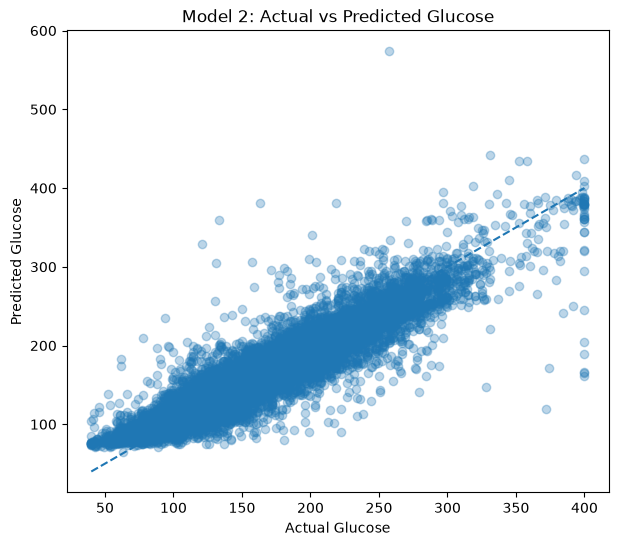

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    ygi_test_np,
    ygi_pred,
    alpha=0.3
)

plt.plot(
    [ygi_test_np.min(), ygi_test_np.max()],
    [ygi_test_np.min(), ygi_test_np.max()],
    linestyle="--"
)

plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Model 2: Actual vs Predicted Glucose")

plt.show()

In [66]:
errors_gi = ygi_pred - ygi_test_np
absolute_errors_gi = np.abs(errors_gi)

print("Mean Error:", errors_gi.mean())
print("Mean Absolute Error:", absolute_errors_gi.mean())
print("Maximum Absolute Error:", absolute_errors_gi.max())

Mean Error: 0.08971958
Mean Absolute Error: 16.398567
Maximum Absolute Error: 316.4613


In [67]:
error_analysis = pd.DataFrame({
    "Actual": ygi_test_np,
    "Predicted": ygi_pred,
    "Error": errors_gi,
    "Absolute_Error": absolute_errors_gi
})

worst_predictions = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(20)

print(worst_predictions)

       Actual   Predicted       Error  Absolute_Error
10262   257.0  573.461304  316.461304      316.461304
6397    372.0  119.925919 -252.074081      252.074081
6398    400.0  161.118408 -238.881592      238.881592
9878    400.0  164.899261 -235.100739      235.100739
9919    400.0  166.447037 -233.552963      233.552963
9949    133.0  358.808868  225.808868      225.808868
9948    163.0  381.614746  218.614746      218.614746
9879    400.0  189.206787 -210.793213      210.793213
9950    121.0  329.500641  208.500641      208.500641
9877    374.0  171.103485 -202.896515      202.896515
9918    400.0  204.163727 -195.836273      195.836273
6396    328.0  146.874878 -181.125122      181.125122
9951    131.0  304.677124  173.677124      173.677124
9947    219.0  381.267731  162.267731      162.267731
6399    400.0  244.998535 -155.001465      155.001465
10198   157.0  306.673767  149.673767      149.673767
9880    384.0  240.920547 -143.079453      143.079453
9917    392.0  249.941803 -1

In [68]:
print("Error percentiles:")

for p in [50, 75, 90, 95, 99, 100]:
    print(
        f"{p}%:",
        np.percentile(absolute_errors_gi, p)
    )

Error percentiles:
50%: 12.159302
75%: 21.854664
90%: 34.407078
95%: 44.964375
99%: 76.76162
100%: 316.4613


In [69]:
error_analysis["Glucose_Range"] = pd.cut(
    error_analysis["Actual"],
    bins=[0, 70, 140, 180, 250, 400, np.inf],
    labels=[
        "Very Low",
        "Normal-ish",
        "Moderately High",
        "High",
        "Very High",
        "Extreme"
    ]
)

range_error = error_analysis.groupby(
    "Glucose_Range",
    observed=False
)["Absolute_Error"].agg(
    ["count", "mean", "median"]
)

print(range_error)

                 count       mean     median
Glucose_Range                               
Very Low           454  24.171326  20.979919
Normal-ish        4669  13.493322  10.313896
Moderately High   3197  13.906427  10.141983
High              3350  17.947693  13.535843
Very High         1189  27.175318  20.005127
Extreme              0        NaN        NaN


In [70]:
# Make a copy of the Model 2 test data
error_check = test_gi.copy()

error_check["Actual"] = ygi_test_np
error_check["Predicted"] = ygi_pred
error_check["Absolute_Error"] = np.abs(
    ygi_pred - ygi_test_np
)

# Show the worst 20 cases
worst_cases = error_check.sort_values(
    "Absolute_Error",
    ascending=False
).head(20)

print(
    worst_cases[
        [
            "Patient",
            "timestamp",
            "glucose_value",
            "Actual",
            "Predicted",
            "Absolute_Error"
        ]
    ].to_string(index=False)
)

        Patient           timestamp  glucose_value  Actual  Predicted  Absolute_Error
584-ws-training 2025-06-26 16:57:00            350   257.0 573.461304      316.461304
567-ws-training 2027-02-04 12:39:15            122   372.0 119.925919      252.074081
567-ws-training 2027-02-04 12:44:15            139   400.0 161.118408      238.881592
584-ws-training 2025-06-25 01:26:00            180   400.0 164.899261      235.100739
584-ws-training 2025-06-25 04:51:00            185   400.0 166.447037      233.552963
584-ws-training 2025-06-25 07:21:00            388   133.0 358.808868      225.808868
584-ws-training 2025-06-25 07:16:00            399   163.0 381.614746      218.614746
584-ws-training 2025-06-25 01:31:00            191   400.0 189.206787      210.793213
584-ws-training 2025-06-25 07:26:00            371   121.0 329.500641      208.500641
584-ws-training 2025-06-25 01:21:00            184   374.0 171.103485      202.896515
584-ws-training 2025-06-25 04:46:00            232   4

In [71]:
patient_errors = (
    error_check
    .groupby("Patient")["Absolute_Error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

print(patient_errors)

                 count       mean     median         max
Patient                                                 
584-ws-training   2372  22.396114  15.786697  316.461304
567-ws-training   2108  17.819042  13.896721  252.074081
540-ws-training   2358  16.720877  13.593876  100.972809
552-ws-training   1774  16.203327  12.813538  139.650879
544-ws-training   2099  13.856057  11.272217  106.317886
596-ws-training   2148  10.673495   7.805389  101.588440


In [72]:
print(
    error_check[
        error_check["Absolute_Error"] > 100
    ][
        [
            "Patient",
            "timestamp",
            "glucose_value",
            "Actual",
            "Predicted",
            "Absolute_Error"
        ]
    ].to_string(index=False)
)

        Patient           timestamp  glucose_value  Actual  Predicted  Absolute_Error
540-ws-training 2027-06-29 10:20:06            154   234.0 133.027191      100.972809
544-ws-training 2027-06-23 08:10:00            161   277.0 170.682114      106.317886
552-ws-training 2025-05-20 23:27:14            290   201.0 340.650879      139.650879
552-ws-training 2025-05-20 23:37:14            278   176.0 280.700317      104.700317
552-ws-training 2025-05-24 09:54:45             68   181.0  80.541115      100.458885
552-ws-training 2025-05-24 09:59:45             70   199.0  90.504326      108.495674
567-ws-training 2027-02-03 21:09:12            344   331.0 441.412872      110.412872
567-ws-training 2027-02-04 12:24:15            113   244.0 129.631149      114.368851
567-ws-training 2027-02-04 12:29:15            121   279.0 141.504959      137.495041
567-ws-training 2027-02-04 12:34:15            127   328.0 146.874878      181.125122
567-ws-training 2027-02-04 12:39:15            122   3